In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold0_with_positions_steps_results.tsv", sep="\t")

fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold1_with_positions_steps_results.tsv", sep="\t")

fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold2_with_positions_steps_results.tsv", sep="\t")

fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
fold3 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold3_with_positions_steps_results.tsv", sep="\t")

fold3["fold"] = [3 for i in range(len(fold3))]

In [6]:
fold4 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold4_with_positions_steps_results.tsv", sep="\t")

fold4["fold"] = [4 for i in range(len(fold4))]

In [7]:
fold5 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold5_with_positions_steps_results.tsv", sep="\t")

fold5["fold"] = [5 for i in range(len(fold5))]

In [8]:
fold6 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold6_with_positions_steps_results.tsv", sep="\t")

fold6["fold"] = [6 for i in range(len(fold6))]

In [9]:
fold7 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold7_with_positions_steps_results.tsv", sep="\t")

fold7["fold"] = [7 for i in range(len(fold7))]

In [10]:
df = pd.concat([fold0, fold1, fold2,
                fold3, fold4, fold5,
                fold6, fold7], ignore_index=True)

In [11]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [12]:
# selecting only sequences with a measurable contact enrichment
df = df[df['URQ_diff'] > 0.0]

In [13]:
training_file = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/gc_content_training_data.tsv"

In [14]:
training_df = pd.read_csv(training_file, sep='\t')
training_gc = training_df['gc_content'].dropna()

In [15]:
edited_gc = df['GC_slice_edited'].dropna()

In [16]:
print(f"Training: n={len(training_gc)}, mean={training_gc.mean():.4f}, std={training_gc.std():.4f}")
print(f"Edited:   n={len(edited_gc)}, mean={edited_gc.mean():.4f}, std={edited_gc.std():.4f}")

Training: n=3864152, mean=0.4183, std=0.0520
Edited:   n=348, mean=0.4774, std=0.0290


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/SLURM_2689039/ipykernel_1305018/1681575004.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([training_gc, edited_gc],
/tmp/SLURM_2689039/ipykernel_1305018/1681575004.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_combined, x='Type', y='GC',


NameError: name 'stats' is not defined

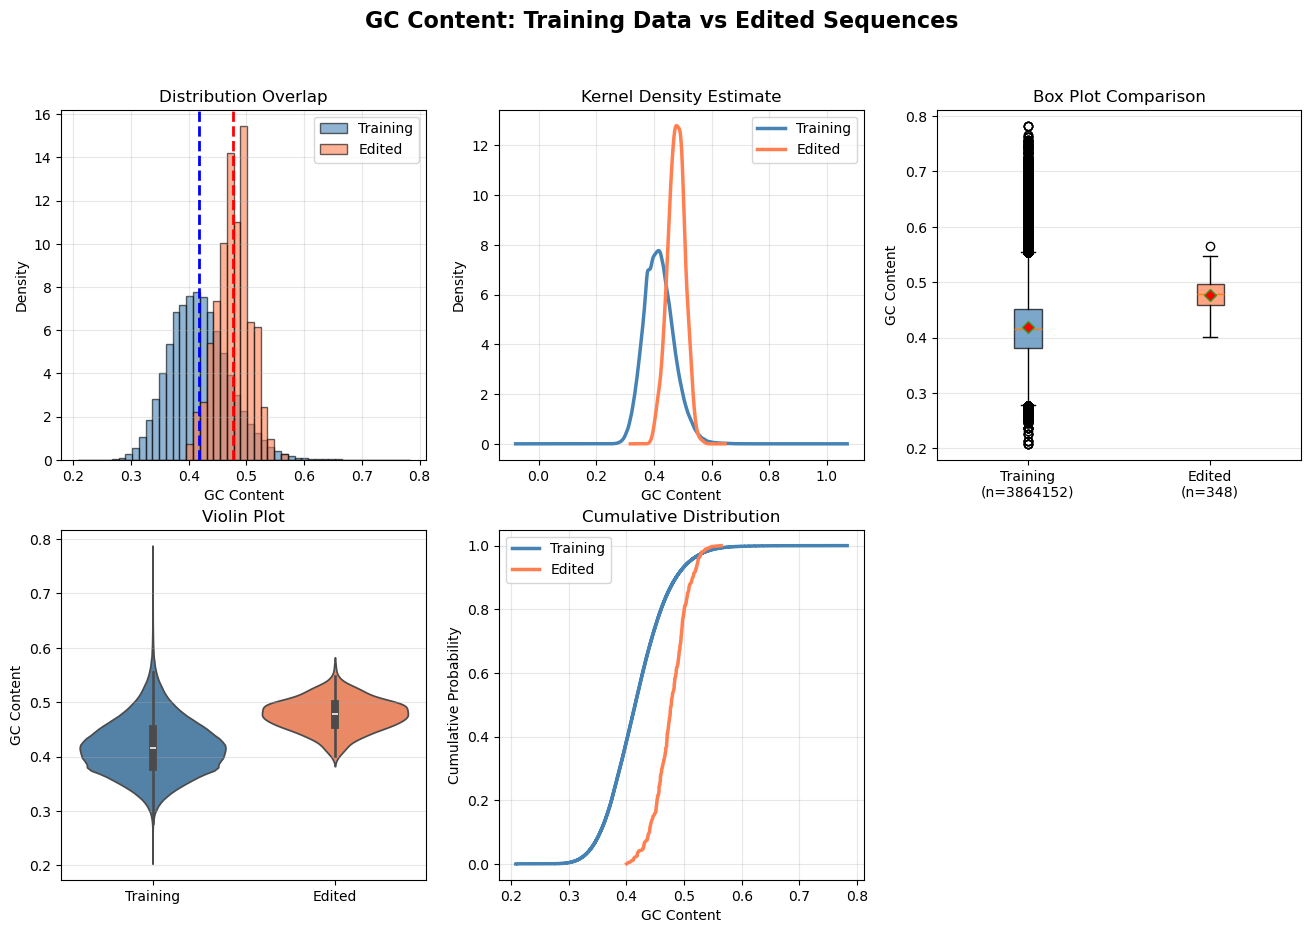

In [18]:
# Create comparison plot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('GC Content: Training Data vs Edited Sequences', fontsize=16, fontweight='bold')

# 1. Overlapping histograms
ax = axes[0, 0]
bins = np.linspace(min(training_gc.min(), edited_gc.min()), 
                   max(training_gc.max(), edited_gc.max()), 50)
ax.hist(training_gc, bins=bins, alpha=0.6, label='Training', 
        color='steelblue', density=True, edgecolor='black')
ax.hist(edited_gc, bins=bins, alpha=0.6, label='Edited', 
        color='coral', density=True, edgecolor='black')
ax.axvline(training_gc.mean(), color='blue', linestyle='--', linewidth=2)
ax.axvline(edited_gc.mean(), color='red', linestyle='--', linewidth=2)
ax.set_xlabel('GC Content')
ax.set_ylabel('Density')
ax.set_title('Distribution Overlap')
ax.legend()
ax.grid(alpha=0.3)

# 2. KDE plot
ax = axes[0, 1]
training_gc.plot(kind='kde', ax=ax, color='steelblue', linewidth=2.5, label='Training')
edited_gc.plot(kind='kde', ax=ax, color='coral', linewidth=2.5, label='Edited')
ax.set_xlabel('GC Content')
ax.set_ylabel('Density')
ax.set_title('Kernel Density Estimate')
ax.legend()
ax.grid(alpha=0.3)

# 3. Box plot
ax = axes[0, 2]
bp = ax.boxplot([training_gc, edited_gc], 
                 labels=[f'Training\n(n={len(training_gc)})', 
                        f'Edited\n(n={len(edited_gc)})'],
                 patch_artist=True, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
for box in bp['boxes']:
    box.set_alpha(0.7)
ax.set_ylabel('GC Content')
ax.set_title('Box Plot Comparison')
ax.grid(alpha=0.3, axis='y')

# 4. Violin plot
ax = axes[1, 0]
data_combined = pd.DataFrame({
    'GC': list(training_gc) + list(edited_gc),
    'Type': ['Training']*len(training_gc) + ['Edited']*len(edited_gc)
})
sns.violinplot(data=data_combined, x='Type', y='GC', 
               palette=['steelblue', 'coral'], ax=ax)
ax.set_ylabel('GC Content')
ax.set_xlabel('')
ax.set_title('Violin Plot')
ax.grid(alpha=0.3, axis='y')

# 5. Cumulative distribution
ax = axes[1, 1]
training_sorted = np.sort(training_gc)
edited_sorted = np.sort(edited_gc)
ax.plot(training_sorted, np.linspace(0, 1, len(training_sorted)), 
        color='steelblue', linewidth=2.5, label='Training')
ax.plot(edited_sorted, np.linspace(0, 1, len(edited_sorted)), 
        color='coral', linewidth=2.5, label='Edited')
ax.set_xlabel('GC Content')
ax.set_ylabel('Cumulative Probability')
ax.set_title('Cumulative Distribution')
ax.legend()
ax.grid(alpha=0.3)

# 6. Statistical summary
ax = axes[1, 2]
ax.axis('off')
# Calculate statistics
t_stat, t_pval = stats.ttest_ind(training_gc, edited_gc)
u_stat, u_pval = stats.mannwhitneyu(training_gc, edited_gc)
ks_stat, ks_pval = stats.ks_2samp(training_gc, edited_gc)
cohens_d = (edited_gc.mean() - training_gc.mean()) / np.sqrt((training_gc.std()**2 + edited_gc.std()**2) / 2)

stats_text = f"""
Statistics Summary

Mean Difference:
  {edited_gc.mean() - training_gc.mean():+.5f}

T-test:
  t = {t_stat:.3f}
  p = {t_pval:.4e}
  {'***' if t_pval < 0.001 else '**' if t_pval < 0.01 else '*' if t_pval < 0.05 else 'ns'}

Mann-Whitney U:
  U = {u_stat:.1f}
  p = {u_pval:.4e}
  {'***' if u_pval < 0.001 else '**' if u_pval < 0.01 else '*' if u_pval < 0.05 else 'ns'}

KS test:
  D = {ks_stat:.4f}
  p = {ks_pval:.4e}
  {'***' if ks_pval < 0.001 else '**' if ks_pval < 0.01 else '*' if ks_pval < 0.05 else 'ns'}

Cohen's d: {cohens_d:.4f}
({('Negligible' if abs(cohens_d) < 0.2 else 'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large')})
"""

ax.text(0.1, 0.9, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
# plt.savefig('gc_comparison.png', dpi=300, bbox_inches='tight')
# print("\nPlot saved to: gc_comparison.png")
plt.show()

In [19]:
# Print detailed statistics
print("\n" + "="*60)
print("DETAILED STATISTICAL COMPARISON")
print("="*60)
print(f"\nTraining data (n={len(training_gc)}):")
print(f"  Mean:   {training_gc.mean():.6f}")
print(f"  Median: {training_gc.median():.6f}")
print(f"  Std:    {training_gc.std():.6f}")
print(f"  Range:  [{training_gc.min():.4f}, {training_gc.max():.4f}]")

print(f"\nEdited sequences (n={len(edited_gc)}):")
print(f"  Mean:   {edited_gc.mean():.6f}")
print(f"  Median: {edited_gc.median():.6f}")
print(f"  Std:    {edited_gc.std():.6f}")
print(f"  Range:  [{edited_gc.min():.4f}, {edited_gc.max():.4f}]")

print(f"\nDifference (Edited - Training):")
print(f"  Mean:   {edited_gc.mean() - training_gc.mean():+.6f}")
print(f"  Median: {edited_gc.median() - training_gc.median():+.6f}")

print("="*60)


DETAILED STATISTICAL COMPARISON

Training data (n=3864152):
  Mean:   0.418325
  Median: 0.415039
  Std:    0.052002
  Range:  [0.2080, 0.7827]

Edited sequences (n=348):
  Mean:   0.477379
  Median: 0.477783
  Std:    0.029026
  Range:  [0.4004, 0.5645]

Difference (Edited - Training):
  Mean:   +0.059054
  Median: +0.062744


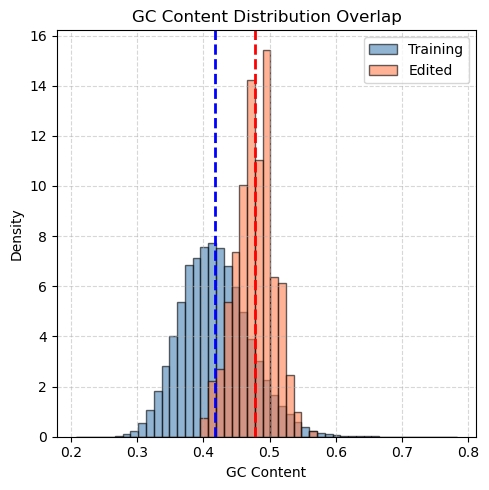

In [25]:
# 1. Create a standalone figure for the first plot
plt.figure(figsize=(5, 5))

# 2. Define bins based on your data
bins = np.linspace(min(training_gc.min(), edited_gc.min()), 
                   max(training_gc.max(), edited_gc.max()), 50)

# 3. Plot the histograms
plt.hist(training_gc, bins=bins, alpha=0.6, label='Training', 
         color='steelblue', density=True, edgecolor='black')
plt.hist(edited_gc, bins=bins, alpha=0.6, label='Edited', 
         color='coral', density=True, edgecolor='black')

# 4. Add mean lines
plt.axvline(training_gc.mean(), color='blue', linestyle='--', linewidth=2)
plt.axvline(edited_gc.mean(), color='red', linestyle='--', linewidth=2)

# 5. Labels and Formatting
plt.xlabel('GC Content')
plt.ylabel('Density')
plt.title('GC Content Distribution Overlap')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 6. Save as SVG
plt.tight_layout()
plt.savefig('gc_distribution_overlap.svg', format='svg', bbox_inches='tight')
plt.show()

# print("Plot saved as gc_distribution_overlap.svg")